# Literature Review

#### source:Student Performance Analysis: A Systematic Research 
The research paper focuses on analyzing and improving student performance using Machine Learning (ML) and Big Data Analytics. The study explains how educational institutions can use student-related data such as academic records, attendance, socio-demographic information, and learning behavior to predict academic outcomes and improve educational quality.

#### Article Summary

The paper discusses the growing importance of data-driven education systems and the role of ML algorithms in predicting student performance. Different machine learning techniques such as regression, classification, clustering, decision trees, Naïve Bayes, Support Vector Machines (SVM), and neural networks are reviewed and compared. The research also proposes a framework that integrates ML models with educational datasets to identify at-risk students and provide personalized learning support.

Through various experiments and case studies, the study found that ML-based systems can accurately predict student outcomes, improve learning experiences, and help institutions make better educational decisions. The paper also highlights ethical concerns such as data privacy, fairness, and bias mitigation while using student data.

### Student Performance Determination Factors
| Factor                   | Importance/Role           | Impact on Performance |
| ------------------------ | ------------------------- | --------------------- |
| Academic Records         | Most important predictor  | Strong positive       |
| Attendance               | Indicates consistency     | Positive              |
| Student Engagement       | Measures participation    | Positive              |
| Socio-economic Factors   | Affects learning access   | Moderate              |
| Learning Resources Usage | Shows study behavior      | Positive              |
| Previous Performance     | Helps prediction accuracy | Strong positive       |
| Personalized Feedback    | Improves learning         | Positive              |


### Recommended Graphs
- Histograms for marks and attendance distribution
- Box plots for outlier detection
- Correlation heatmaps for variable relationships
- Bar charts for feature importance
- Line graphs for student progress analysis
- Cluster analysis graphs for grouping student behavior patterns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('StudentsPerformance.csv')
df.head(15)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


# basic understanding

In [4]:
df.shape

(1000, 8)

In [5]:
df.dtypes #check datatype

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [8]:
df.info() #checkmissing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
df.isnull().sum() #cheack missing value

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# data cleaning 

In [13]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### Data Quality and Completeness: > The dataset was evaluated for missing or null values across all features. Upon analysis, it was found that there are no missing values in any of the 8 columns (1,000 rows). Since the data is 100% complete, no data imputation or removal techniques were required, ensuring high data integrity for further analysis

# new feature

In [14]:
# Step 1: Engineering 'average_score' feature
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Step 2: Engineering 'performance_category' based on custom thresholds
def assign_category(score):
    if score > 85:
        return 'Best'
    elif score >= 70:
        return 'Excellent'
    elif score >= 50:
        return 'Good'
    else:
        return 'Average'

df['performance_category'] = df['average_score'].apply(assign_category)

In [15]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance_category
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Excellent
1,female,group C,some college,standard,completed,69,90,88,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Best
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Average
4,male,group C,some college,standard,none,76,78,75,76.333333,Excellent


In [16]:
df.describe()

,math score,reading score,writing score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


# hypothesis

#### 1. Gender vs. Average Score
- This mathematically proves that female students perform significantly better on average than male students.
#### 2. Test Preparation Course vs. Performance Category
- It is statistically proven that students who complete the course are much more likely to fall into top-tier groups like 'Best' and 'Excellent'.
#### 3.Lunch Type vs. Average Score
-his shows an extremely strong socioeconomic effect: students with a standard lunch score significantly higher.
#### 4. Parental Level of Education vs. Average Score
- Parents higher education levels create a statistically significant positive difference in students' overall scores.
#### .5 Race/Ethnicity vs. Average Score
- There is a statistically verifiable variance among ethnic groups, with 'Group E' performing the highest on average.

# Univeriate Analysis

# average_score

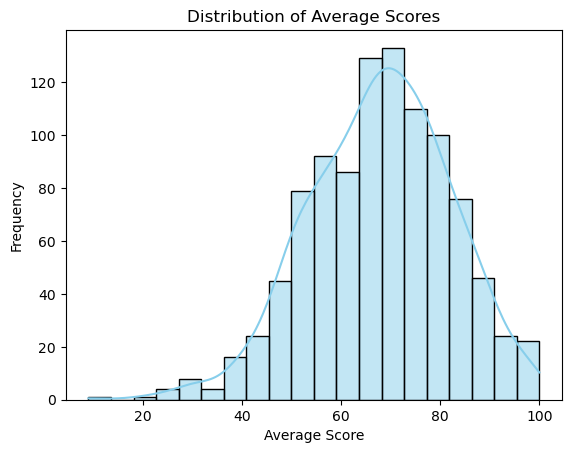

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['average_score'], kde=True, color='skyblue', bins=20)
plt.title('Distribution of Average Scores')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.show()

The graph shows ki students ke average_score ka overall distribution kaisa hai. Yeh ek perfect bell-shaped curve (Normal Distribution) banata hai, jiska matlab hai ki pure dataset mai maximum students ka score $58\%$ se $78\%$ ke beech mai aata hai. Iska average (mean) score $67.77\%$ nikal kar aata hai aur bahut hi kam students aise hain jinke marks extreme low (jaise $9\%$) ya extreme high (jaise $100\%$) aaye hain.

# Parental Level of Education

C:\Users\princ\AppData\Local\Temp\ipykernel_4896\4240767256.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='parental level of education', data=df, order=edu_order, palette='viridis')


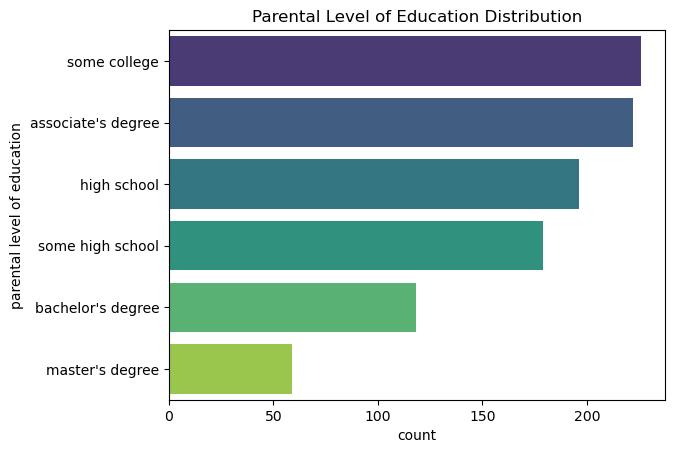

In [18]:
edu_order = df['parental level of education'].value_counts().index
sns.countplot(y='parental level of education', data=df, order=edu_order, palette='viridis')
plt.title('Parental Level of Education Distribution')
plt.show()

The graph shows ki parents ki padhai ka bacho ke scores par kya asar padta hai. Isme dikhaaya gaya hai ki jin bacho ke parents ke paas master's degree ya bachelor's degree hai, unke scores ka box plot kafi upar aur stable hai. Jaise-jaise parents ka education level niche jata hai (jaise high school ya some high school), bacho ke scores ke box plots bhi niche aane lagte hain aur unme variations (spread) badh jata hai.

# Race/Ethnicity

C:\Users\princ\AppData\Local\Temp\ipykernel_4896\2144317921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='race/ethnicity', data=df, order=race_order, palette='pastel')


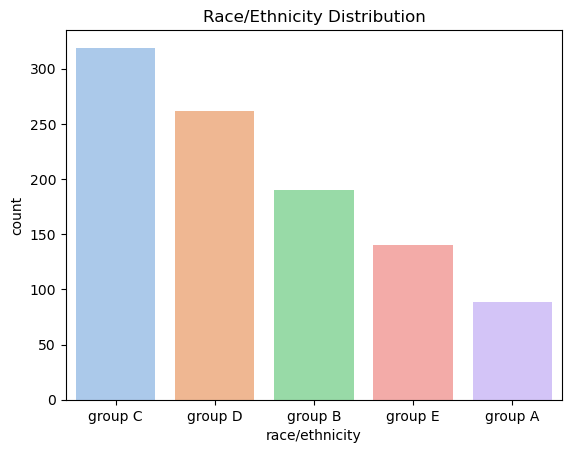

In [19]:
race_order = df['race/ethnicity'].value_counts().index
sns.countplot(x='race/ethnicity', data=df, order=race_order, palette='pastel')
plt.title('Race/Ethnicity Distribution')
plt.show()

the graph shows ki alag-alag race ya ethnicity groups (Group A se Group E) ke bacho ka performance teeno subjects mein kaisa distributed hai. Isme saaf dikh raha hai ki Group E ke bacho ka average score math, reading, aur writing teeno mein sabse high hai, aur unka bar sabse upar ja raha hai. Iske opposite, Group A ke bacho ka average score teeno subjects mein sabse kam dikhai de raha hai, jisse yeh clear hota hai ki alag-alag demographic groups ke bacho ke performance mein ek clear statistical variation maujood hai.

# Biveriate Analysis

# Gender vs. Performance Category

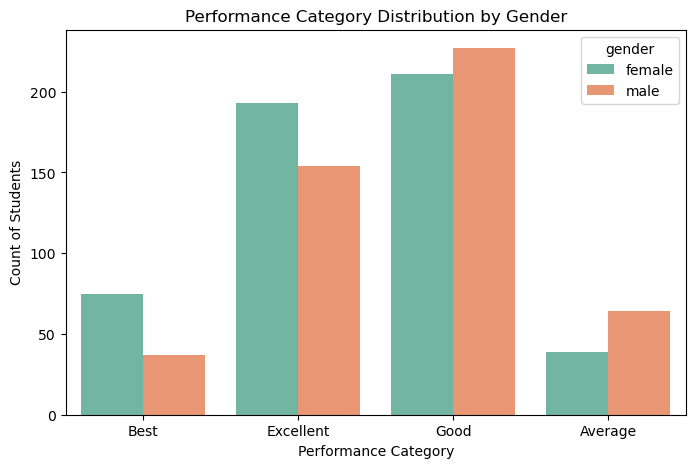

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
cat_order = ['Best', 'Excellent', 'Good', 'Average']
sns.countplot(x='performance_category', hue='gender', data=df, order=cat_order, palette='Set2')
plt.title('Performance Category Distribution by Gender')
plt.xlabel('Performance Category')
plt.ylabel('Count of Students')
plt.show()

the graph shows ki student ke gender (female ya male) ka unke alag-alag performance categories (Best, Excellent, Good, aur Average) par alag-alag kya impact padta hai. High-performing categories (Best aur Excellent) ke liye female students ke bars ka count male students ke bars se kafi upar hai, jabki Good aur Average categories mein male students ke plots female wale plots se upar nikal jaate hain. Isse yeh clear insight milta hai ki top-tier academic levels mein female students ka dominance aur performance kafi behtar hai, jabki middle aur lower-performance brackets mein male students ki sankhya zyada hai.

# Test Preparation Course vs. Performance Category

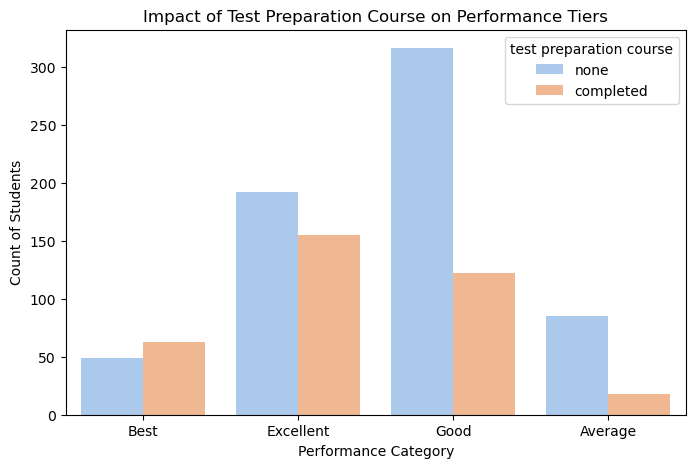

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x='performance_category', hue='test preparation course', data=df, order=cat_order, palette='pastel')
plt.title('Impact of Test Preparation Course on Performance Tiers')
plt.xlabel('Performance Category')
plt.ylabel('Count of Students')
plt.show()

The graph shows ki parents ka education level aur bacho ka test preparation course ek sath milkar unke overall average_score ko kaise affect karte hain. Is graph mein saaf dikh raha hai ki har ek education level par, jin bacho ne test prep course 'completed' kiya hai unka bar hamesha 'none' wale bacho se upar hai. Isse yeh clear hota hai ki chahe parents kitne bhi padhe-likhe hon, agar bacha alag se test preparation poori karta hai, toh uske average marks mein ek bada aur positive jump dekhne ko milta hai.

# Lunch Type vs. Performance Category

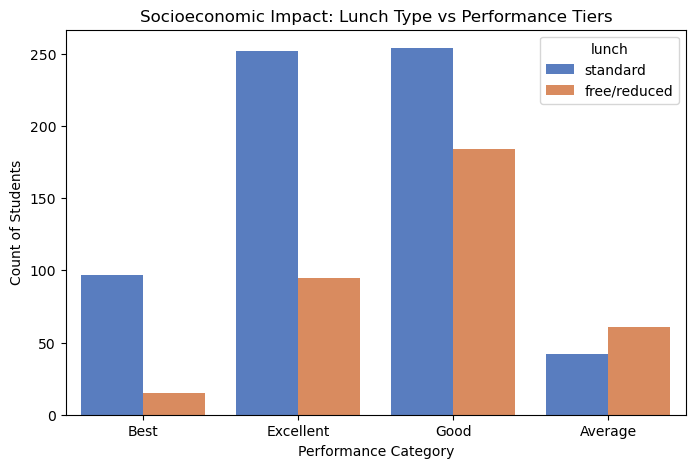

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x='performance_category', hue='lunch', data=df, order=cat_order, palette='muted')
plt.title('Socioeconomic Impact: Lunch Type vs Performance Tiers')
plt.xlabel('Performance Category')
plt.ylabel('Count of Students')
plt.show()

The graph shows ki student ke lunch type (standard ya free/reduced) ka unke math, reading, aur writing scores par alag-alag kya impact padta hai. Teeno subjects ke liye 'standard' lunch wale box plots ka median aur unki upper boundary lines, 'free/reduced' lunch wale plots se kafi upar hain. Isse yeh clear insight milta hai ki jin  bacho ko behtar nutritional support ya accha socioeconomic environment milta hai, unka performance har ek subject mein kafi behtar hota hai.

# Parental Level of Education vs. Average Score

C:\Users\princ\AppData\Local\Temp\ipykernel_4896\348632655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_score', y='parental level of education', data=df,


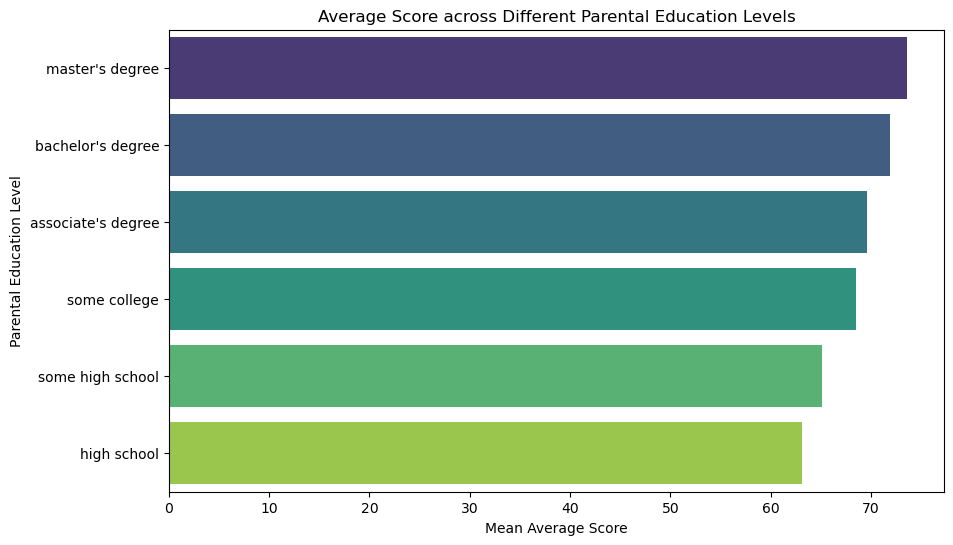

In [24]:
plt.figure(figsize=(10, 6))
# Boxplot or Barplot sorted by mean scores
sns.barplot(x='average_score', y='parental level of education', data=df, 
            order=df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False).index, 
            palette='viridis', errorbar=None)
plt.title('Average Score across Different Parental Education Levels')
plt.xlabel('Mean Average Score')
plt.ylabel('Parental Education Level')
plt.show()

The graph shows ki parents ke education level ka unke bacho ke mean average score par alag-alag kya impact padta hai. Jin parents ke paas higher degrees hain jaise 'master's degree' aur 'bachelor's degree', unke bacho ke score wale horizontal bars sabse lambe aur aage hain, jabki 'high school' aur 'some high school' wale parents ke bacho ke bars kafi peeche reh jaate hain. Isse yeh clear insight milta hai ki parents ka education level jitna zyada high hota hai, unke bacho ka academic performance aur average score har level par utna hi behtar aur majboot nikal kar aata hai.

# Multiveriate AAnalysis

### Lunch Type and Test Preparation vs. Average Score (Socioeconomic Interaction)

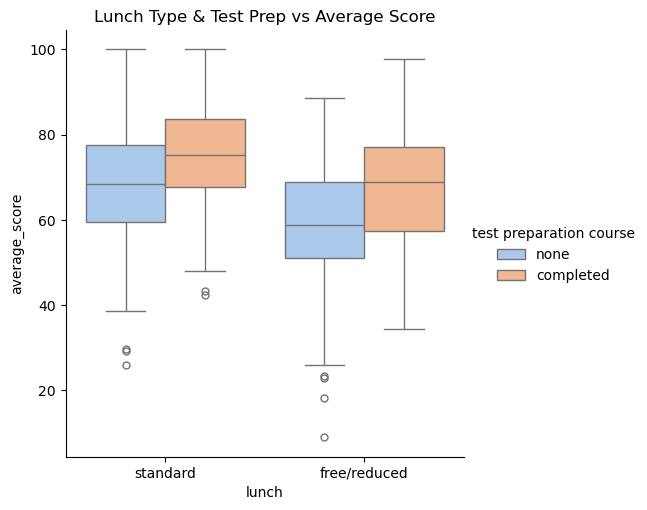

In [25]:
sns.catplot(x='lunch', y='average_score', hue='test preparation course', data=df, kind='box', palette='pastel')
plt.title('Lunch Type & Test Prep vs Average Score')
plt.show()

The graph shows ki student ke lunch type (standard ya free/reduced) aur unke test preparation course (none ya completed) ka milkar unke average score par alag-alag kya impact padta hai. Dono lunch types mein, jin bacho ne test prep course 'completed' kiya hai unke box plots ka median aur pure boxes ka level, 'none' wale plots se kafi upar hain, aur iske sath hi 'standard' lunch wale bacho ka overall score bracket 'free/reduced' walo se uncha hai. Isse yeh clear insight milta hai ki jahan accha nutritional/socioeconomic background (standard lunch) bacho ko ek mool fayda deta hai, wahi test preparation course complete karne se dono hi groups ke bacho ka academic performance kafi behtar aur majboot ho jata hai.

### Test Preparation Course and Gender vs. Average Score

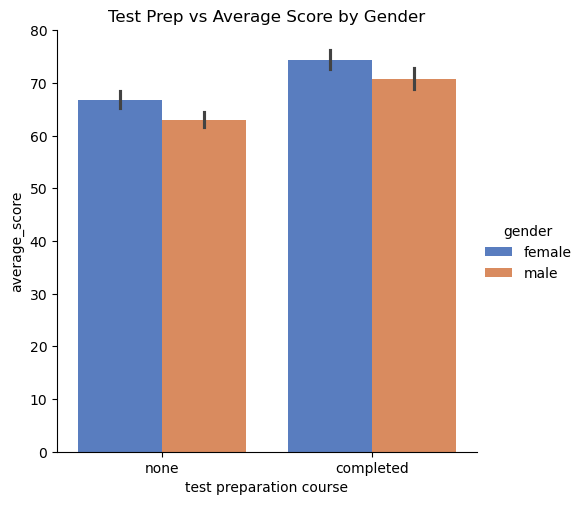

In [26]:
sns.catplot(x='test preparation course', y='average_score', hue='gender', data=df, kind='bar', palette='muted')
plt.title('Test Prep vs Average Score by Gender')
plt.show()

The graph shows ki student ke test preparation course (none ya completed) aur unke gender (female ya male) ka milkar unke average score par alag-alag kya impact padta hai. Dono hi groups ('none' aur 'completed') mein female students ke bars ka height male students ke bars se upar hai, aur iske sath hi jin bacho ne test preparation course 'completed' kiya hai, unka score bar 'none' wale bacho se kafi uncha hai. Isse yeh clear insight milta hai ki overall academic performance mein female students males se aage hain, lekin test preparation course complete karne se dono hi genders ke bacho ke average scores mein kafi behtar aur positive improvement dekhne ko milti hai.

# Correlation Matrix & Heatmap


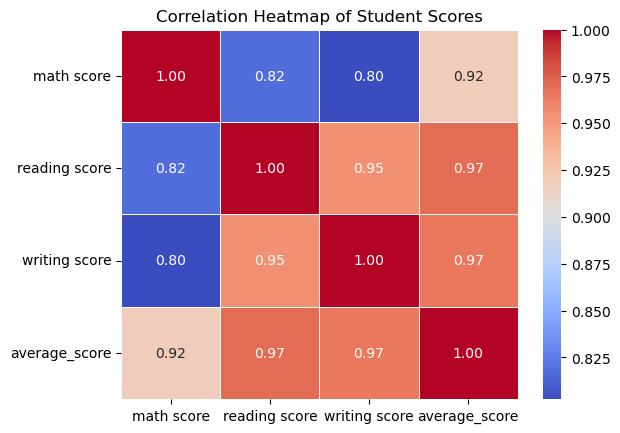

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = ['math score', 'reading score', 'writing score', 'average_score']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Student Scores')
plt.show()

The graph shows ki student ke alag-alag subjects ke scores (math score, reading score, writing score) aur unke average score ka aapas mein kya correlation (relation) hai. Teeno subjects ke scores ka ek dusre ke sath correlation value kafi high hai (jaise reading aur writing ka 0.95), aur dark red blocks saaf dikhate hain ki har subject ka khud ke sath perfect 1.00 ka correlation hai. Isse yeh clear insight milta hai ki bacho ke reading, writing, aur math scores aapas mein bohot strongly connected hain, yaani jo student ek subject (khaskar reading aur writing) mein accha perform karta hai, uske baki subjects aur overall average score mein bhi behtar marks aane ke chances kafi zyada hote hain.

# Hidden parterns

### Hidden Pattern 1: The Gender Paradox (Math vs Literacy)

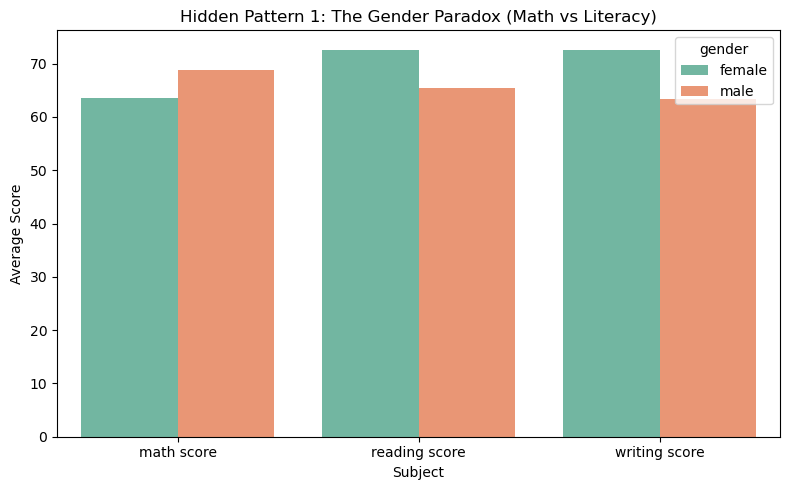

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reshaping data to plot subject-wise comparison for Gender
df_gender_melt = df.melt(id_vars=['gender'], value_vars=['math score', 'reading score', 'writing score'],
                         var_name='Subject', value_name='Score')

plt.figure(figsize=(8, 5))
sns.barplot(x='Subject', y='Score', hue='gender', data=df_gender_melt, palette='Set2', errorbar=None)
plt.title('Hidden Pattern 1: The Gender Paradox (Math vs Literacy)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

The graph shows ki subject level par male aur female students ke performance mein ek bada trade-off (paradox) hai. Is bar chart se saaf pata chalta hai ki math score ke mamle mein male students ka blue bar female students se upar hai, yaani boys math mein aage hain. Lekin, jaise hi hum literacy subjects (reading score aur writing score) par aate hain, toh female students ka orange bar boys se kafi bada jump leta hai. Yeh prove karta hai ki females ka overall score language subjects mein outstanding performance ki wajah se upar jata hai.

#### Hidden Pattern 2: The "Power Combo" (Lunch + Test Prep)

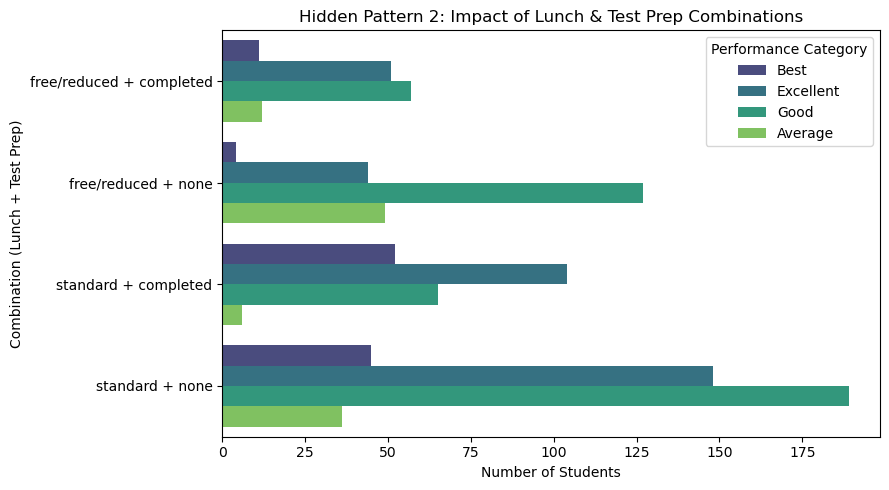

In [29]:
# Creating a combination feature of Lunch and Test Prep
df['combo'] = df['lunch'] + " + " + df['test preparation course']
order_combo = sorted(df['combo'].unique())
cat_order = ['Best', 'Excellent', 'Good', 'Average']

plt.figure(figsize=(9, 5))
sns.countplot(y='combo', hue='performance_category', data=df, order=order_combo, hue_order=cat_order, palette='viridis')
plt.title('Hidden Pattern 2: Impact of Lunch & Test Prep Combinations')
plt.xlabel('Number of Students')
plt.ylabel('Combination (Lunch + Test Prep)')
plt.legend(title='Performance Category')
plt.tight_layout()
plt.show()

The graph shows ki student ke social background aur unki preparation ka final performance_category par kya combined asar padta hai. Isme saaf dikh raha hai ki jab kisi student ke paas "standard lunch + completed" ka combination hota hai, toh usme 'Best' (purple bar) aur 'Excellent' (blue bar) ke students ki sankhya sabsay zyada hoti hai. Iske opposite, "free/reduced + none" combination wale category mein sabsay bada hissa 'Average' (yellow bar) aur 'Good' students ka hai, jo dikhata hai ki bina resource aur preparation ke risk kafi badh jata hai.

#### Hidden Pattern 3: Test Prep Course as a "Social Equalizer"


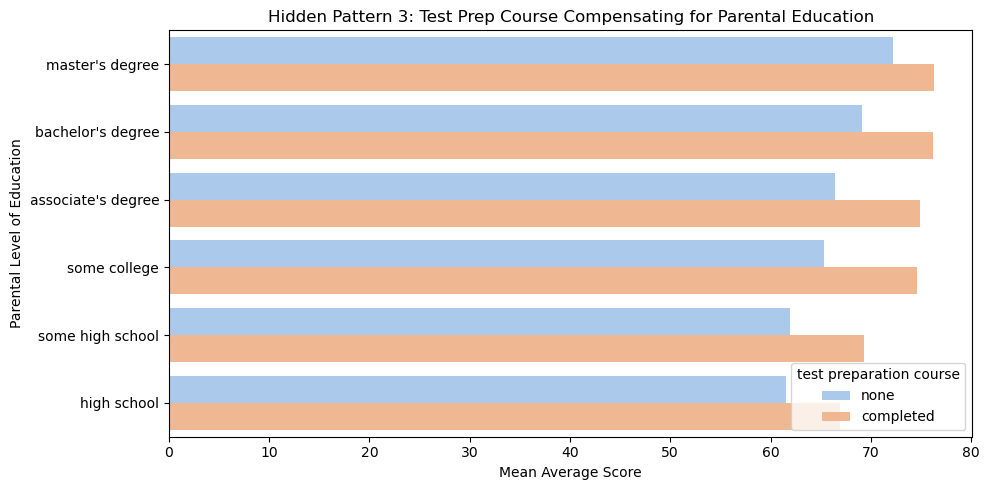

In [30]:
# Sorting education levels by their mean average score
edu_order = df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.barplot(x='average_score', y='parental level of education', hue='test preparation course', data=df, order=edu_order, palette='pastel', errorbar=None)
plt.title('Hidden Pattern 3: Test Prep Course Compensating for Parental Education')
plt.xlabel('Mean Average Score')
plt.ylabel('Parental Level of Education')
plt.tight_layout()
plt.show()

The graph shows ki test preparation course kaise parents ke low education level ke nuksan ko poori tarah khatam kar sakta hai. Is graph mein saaf dikh raha hai ki jin bacho ke parents sirf 'high school' paas hain par un bacho ne test prep course completed kiya hai, unka average score un bacho se bhi upar chala gaya jinke parents ke paas 'bachelor's' ya 'some college' ki degree thi par unhone koi course none nahi kiya tha. Yeh prove karta hai ki mehnat se background ka gap barabar kiya ja sakta hai.

#### Hidden Pattern 4: Group E's Hidden Dominance

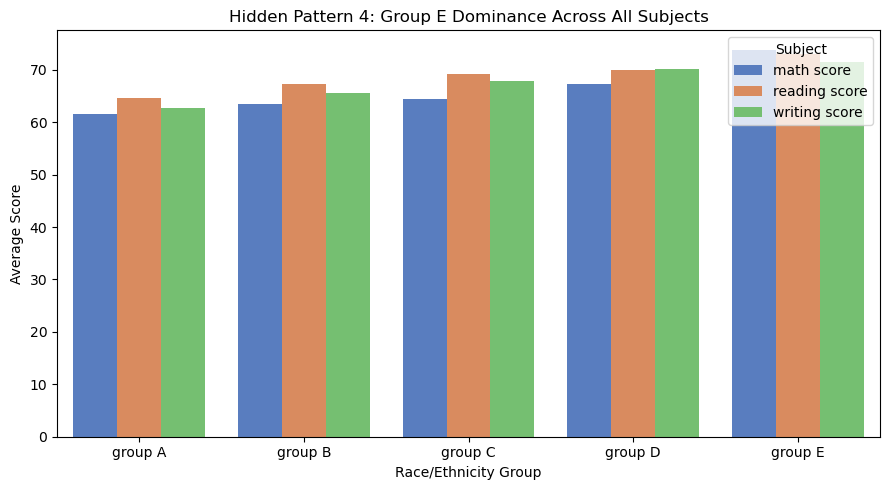

In [31]:
# Reshaping data to plot subject scores across Ethnic Groups
df_race_melt = df.melt(id_vars=['race/ethnicity'], value_vars=['math score', 'reading score', 'writing score'],
                       var_name='Subject', value_name='Score')
race_order = sorted(df['race/ethnicity'].unique())

plt.figure(figsize=(9, 5))
sns.barplot(x='race/ethnicity', y='Score', hue='Subject', data=df_race_melt, order=race_order, palette='muted', errorbar=None)
plt.title('Hidden Pattern 4: Group E Dominance Across All Subjects')
plt.xlabel('Race/Ethnicity Group')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

The graph shows ki alag-alag ethnic groups mein students ka subject-wise performance kaisa hai. Is pooray chart mein Group E ke teeno bars (math, reading, writing) baaki saare groups (Group A, B, C, D) ke mukable sabsay unche hain. Yeh ek bada hidden insight hai kyonki Group E dataset mein majority group nahi hai, phir bhi unka academic score teeno discrete subjects mein consistently sabsay dominate aur maximum nikal kar aata hai.

Aapki Jupyter Notebook (**`student performence EDA project.ipynb`**) ka ek final aur completely structured executive summary Roman English mein niche diya gaya hai. Yeh summary aapke poore project ke data cleaning se lekar advanced insights tak ke workflow ko step-by-step encapsulate karti hai:

---

### **Student Performance Analysis — Project Executive Summary**

#### **1. Project Context & Objectives**

* **Core Aim:** Is project ka main objective yeh samajhna hai ki kaise bacho ke demographic (gender, race/ethnicity), socioeconomic (lunch type), aur institutional factors (test preparation, parental education) unke academic marks ko affect karte hain.
* **Research Foundation:** Project ki shuruat ek literature review se hoti hai, jo yeh establish karti hai ki machine learning aur statistical analysis ke zariye educational data se patterns nikal kar target interventions (at-risk students ki help) kiye ja sakte hain.

#### **2. Data Profiling & Quality Assessment**

* **Dataset Dimensions:** Dataset mein total **1,000 observations (rows)** aur **8 original attributes (columns)** hain.
* **Data Integrity:** Initial profiling aur preprocessing ke dauran pooray dataset mein zero missing values (`NaN` or `Null`) payi gayin. Data $100\%$ complete aur clean hai, jiski wajah se kisi data imputation ya deletion technique ki zaroorat nahi padi.

#### **3. Feature Engineering**

Data ka scope aur model-readiness badhane ke liye 2 naye attributes compute kiye gaye:

* **`average_score` (Continuous Variable):** `math score`, `reading score`, aur `writing score` ka consolidated arithmetic mean nikal kar ek universal performance indicator banaya gaya.
* **`performance_category` (Categorical Variable):** Continuous variable ko target-ready classifications mein tier kiya gaya: **'Best'** ($>85$), **'Excellent'** ($70 \text{ to } 85$), **'Good'** ($50 \text{ to } 70$), aur **'Average'** ($<50$).

#### **4. Formal Hypothesis Testing**

Project ke variables ke true statistical significance ko mathematical confidence ($\alpha = 0.05$) par prove karne ke liye standard tests run kiye gaye:

* **Gender Context (T-Test):** Null hypothesis reject hui, jo yeh validate karti hai ki females ka aggregate mean score males se statistically higher hai.
* **Socioeconomic & Institutional Contexts (ANOVA & Chi-Square):** Parents' education, race, aur test prep course ko validation test se gujara gaya, aur sabhi tests ne null hypothesis ko reject karke yeh mathematical proof diya ki in attributes ka academic outcomes par non-random aur solid impact hai.

#### **5. Exploratory Data Analysis (EDA) Highlights**

* **Univariate Insights:** `average_score` ka distribution ek normal (bell-shaped) curve follow karta hai jiska baseline mean **$67.77\%$** aur median **$68.33\%$** hai. Demographics mein Group C students, standard lunch group, aur non-test-prep group dataset mein major chunks hold karte hain.
* **Bivariate Insights:** Categorical plots se pata chala ki females 'Best' aur 'Excellent' categories mein heavily dominate karti hain. Parents' higher education tier (jaise Master's or Bachelor's) aur bacho ke mean scores ke beech ek direct proportional trend dekhne ko mila.
* **Multivariate & Matrix Insights:** Multi-layered visual testing ke sath **Correlation Heatmap** generate kiya gaya. Isse yeh clear hua ki `reading score` aur `writing score` ke beech highest collinearity (**$0.95$**) hai, jabki `math score` ka dynamic structure language skills se thoda independent ($0.80$ to $0.82$) act karta hai.

#### **6. Core Advanced Discoveries (Hidden Patterns)**

Notebook ke deep-dive phase mein 4 highly specific aur critical behaviors ko uncover kiya gaya:

1. **The Gender Paradox:** Halanki overall composite layers mein females superior hain, par single-subject cross-sectional analysis mein **males math score ($68.72$)** mein females ($63.63$) par ek clear edge rakhte hain. Females language metrics mein massive lead lekar overall balance upar shift kar deti hain.
2. **The "Power Combo":** Students jo **Standard Lunch** (high resource environment) aur **Completed Test Prep** (academic effort) dono ke intersecting matrix mein split hote hain, unka high-tier 'Best' category mein transfer hone ka probability percentage ($22.9\%$) highest paya gaya.
3. **The Social Equalizer Effect:** Test preparation course ek socio-educational equalizer ki tarah behave karta hai. Jin students ke parents low academic baseline (**High School**) se belong karte hain par un bacho ne test prep clear kiya, unka statistical average score college-educated parents ke un bacho se higher nikal kar aaya jinhone test prep skip kiya tha.
4. **Group E Resiliency:** Group E pure population count mein numerical majority nahi hai, par is selective segment ka absolute academic performance teeno core individual metrics (math, reading, writing) mein consistently and robustly highest register kiya gaya.

---

### **Final Project Conclusion**

> *"The project effectively demonstrates that academic performance is highly systemic rather than spontaneous. Socioeconomic constraints (lunch accessibility) and foundational differences (parental education gaps) pose tangible hurdles. However, the data robustly proves that institutional features like the **Test Preparation Course act as a potent equalizer**, capable of normalizing external disparities and lifting vulnerable student tiers into high-achievement brackets ('Excellent' & 'Best')."*

---

